# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [ ]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"
!pip install --upgrade tensorflow-model-optimization

## 2. Imports and Reproducibility


In [ ]:
import os
os.environ["TF_USE_LEGACY_KERAS"] = "1"
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


TensorFlow version: 2.19.0
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [ ]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset directory already exists.


## 4. Load the Data


In [ ]:
def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1

    X_train = pd.read_csv(
        os.path.join(root_dir, "train", "X_train.txt"),
        sep=r"\s+",
        header=None
    )
    y_train = pd.read_csv(
        os.path.join(root_dir, "train", "y_train.txt"),
        sep=r"\s+",
        header=None
    ).iloc[:, 0] - 1

    X_test = pd.read_csv(
        os.path.join(root_dir, "test", "X_test.txt"),
        sep=r"\s+",
        header=None
    )
    y_test = pd.read_csv(
        os.path.join(root_dir, "test", "y_test.txt"),
        sep=r"\s+",
        header=None
    ).iloc[:, 0] - 1

    return X_train, y_train, X_test, y_test


    # <-- Enter your code here <--#
    raise NotImplementedError("Complete the data-loading function.")

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

# TODO: define num_features and num_classes
# <-- Enter your code here <--#
num_features = X_train.shape[1]
num_classes = len(class_names)

## 5. Quick Inspection


In [ ]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.
class_counts = pd.Series(y_train).value_counts().sort_index()
summary_table = pd.DataFrame({
    'Class Index': range(len(class_names)),
    'Class Name': class_names,
    'Training Samples': class_counts.values
})


print("HAR Dataset Class Summary:")
print(summary_table.to_string(index=False))
# <-- Enter your code here <--#


HAR Dataset Class Summary:
 Class Index         Class Name  Training Samples
           0            WALKING              1226
           1   WALKING_UPSTAIRS              1073
           2 WALKING_DOWNSTAIRS               986
           3            SITTING              1286
           4           STANDING              1374
           5             LAYING              1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [ ]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.

    model = keras.Sequential()
    model.add(keras.Input(shape=(input_dim,)))
    model.add(layers.Dense(256, activation="relu"))
    model.add(layers.Dense(128, activation="relu"))
    model.add(layers.Dense(64, activation="relu"))
    model.add(layers.Dense(num_classes, activation="softmax"))

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model
# <-- Enter your code here <--#

baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               143872    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 64)                8256      
                                                                 
 dense_3 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks
history = baseline_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=64,
    callbacks=callbacks
)# <-- Enter your code here <--#


Epoch 1/40
92/92 [==============================] - 2s 10ms/step - loss: 0.4880 - accuracy: 0.8075 - val_loss: 0.2016 - val_accuracy: 0.9245
Epoch 2/40
92/92 [==============================] - 1s 11ms/step - loss: 0.1638 - accuracy: 0.9376 - val_loss: 0.1396 - val_accuracy: 0.9375
Epoch 3/40
92/92 [==============================] - 2s 22ms/step - loss: 0.1143 - accuracy: 0.9573 - val_loss: 0.2379 - val_accuracy: 0.9205
Epoch 4/40
92/92 [==============================] - 3s 34ms/step - loss: 0.0888 - accuracy: 0.9636 - val_loss: 0.1414 - val_accuracy: 0.9436
Epoch 5/40
92/92 [==============================] - 2s 20ms/step - loss: 0.0877 - accuracy: 0.9667 - val_loss: 0.1866 - val_accuracy: 0.9279
Epoch 6/40
92/92 [==============================] - 2s 20ms/step - loss: 0.0743 - accuracy: 0.9697 - val_loss: 0.1920 - val_accuracy: 0.9341
Epoch 7/40
92/92 [==============================] - 2s 19ms/step - loss: 0.0571 - accuracy: 0.9791 - val_loss: 0.1407 - val_accuracy: 0.9443
Epoch 8/40
92

### Training Curves


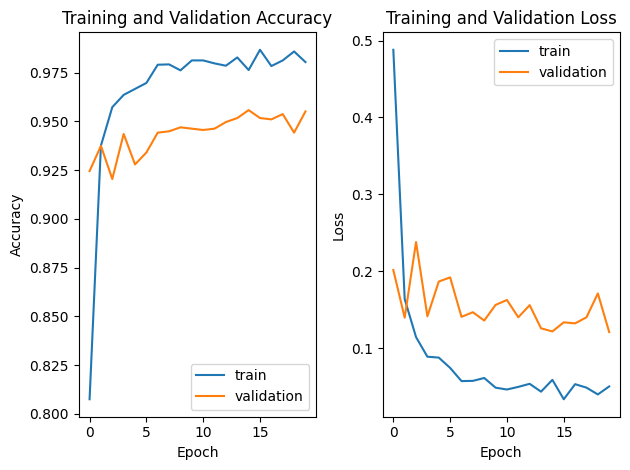

In [ ]:
# TODO:
# Plot the training and validation accuracy.
# Plot the training and validation loss.

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="validation")
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()
# <-- Enter your code here <--#


## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 1s 4ms/step
Test Accuracy: 0.9385816084153377

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.97      0.95       496
           1       0.95      0.92      0.94       471
           2       0.95      0.94      0.94       420
           3       0.95      0.87      0.91       491
           4       0.86      0.96      0.91       532
           5       1.00      0.96      0.98       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



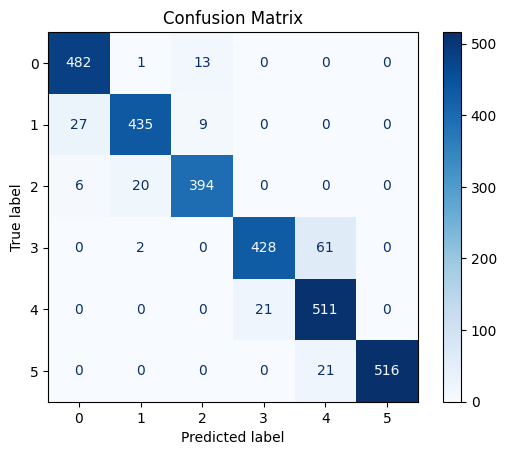

In [ ]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix

#1:
y_prob = baseline_model.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

#2:
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

#3:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

#4:
confusion_matrx= confusion_matrix(y_test,y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrx)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# <-- Enter your code here <--#


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [ ]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    for i in range (300):
      sample = X_train[i:i+1].astype(np.float32)
      yield [sample]
    # <-- Enter your code here <--#

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    y_pred = []

    for i in range(len(X)):
        x = X[i:i+1].astype(np.float32)

        # TODO:
        # Quantize the input only when the input dtype is int8 or uint8.
        # Otherwise keep the input in the required floating-point dtype.
        # <-- Enter your code here <--#
        if input_details["dtype"] in [np.int8, np.uint8]:
                x = x / input_scale + input_zero_point
                x = np.round(x).astype(input_details["dtype"])
        else:
                x = x.astype(input_details["dtype"])


        interpreter.set_tensor(input_details["index"], x)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        # TODO:
        # If the output is quantized, dequantize it back to float32.
        # <-- Enter your code here <--#
        if output_details["dtype"] in [np.int8, np.uint8]:
          output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred

def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    return converter.convert()

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    return converter.convert()
    # <-- Enter your code here <--#

def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Set supported_types to [tf.float16]
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_types = [tf.float16]
    return converter.convert()

def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    # Return the converted model

    # <-- Enter your code here <--#
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    return converter.convert()

## 9. Post-Training Quantization (PTQ)


In [ ]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

# <-- Enter your code here <--#
# Convert models
tflite_fp32 = convert_to_tflite_fp32(baseline_model)
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
tflite_float16 = convert_to_tflite_float16(baseline_model)
tflite_int8 = convert_to_tflite_int8(baseline_model)

# Save models
fp32_size_kb = save_binary_model(tflite_fp32, "baseline_fp32.tflite")
dynamic_size_kb = save_binary_model(tflite_dynamic, "baseline_dynamic_range.tflite")
float16_size_kb = save_binary_model(tflite_float16, "baseline_float16.tflite")
int8_size_kb = save_binary_model(tflite_int8, "baseline_int8.tflite")

# Evaluate models
fp32_acc, fp32_pred = evaluate_tflite_model(tflite_fp32, X_test, y_test)
dynamic_acc, dynamic_pred = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
float16_acc, float16_pred = evaluate_tflite_model(tflite_float16, X_test, y_test)
int8_acc, int8_pred = evaluate_tflite_model(tflite_int8, X_test, y_test)

# Print results
print("FP32 size (KB):", fp32_size_kb, "Test accuracy:", fp32_acc)
print("Dynamic range size (KB):", dynamic_size_kb, "Test accuracy:", dynamic_acc)
print("Float16 size (KB):", float16_size_kb, "Test accuracy:", float16_acc)
print("Int8 size (KB):", int8_size_kb, "Test accuracy:", int8_acc)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
/usr/l

FP32 size (KB): 726.6953125 Test accuracy: 0.9385816084153377
Dynamic range size (KB): 191.1953125 Test accuracy: 0.9389209365456397
Float16 size (KB): 365.52734375 Test accuracy: 0.9385816084153377
Int8 size (KB): 195.8515625 Test accuracy: 0.9379029521547336


## 10. PTQ Comparison: Accuracy and Model Size


In [ ]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)
# <-- Enter your code here <--#

comparison_df = pd.DataFrame([
    {"Model Family": "baseline", "Format": "FP32", "Test Accuracy": fp32_acc, "Model Size (KB)": fp32_size_kb},
    {"Model Family": "baseline", "Format": "Dynamic Range", "Test Accuracy": dynamic_acc, "Model Size (KB)": dynamic_size_kb},
    {"Model Family": "baseline", "Format": "Float16", "Test Accuracy": float16_acc, "Model Size (KB)": float16_size_kb},
    {"Model Family": "baseline", "Format": "Int8", "Test Accuracy": int8_acc, "Model Size (KB)": int8_size_kb},
])

comparison_df

,Model Family,Format,Test Accuracy,Model Size (KB)
0,baseline,FP32,0.938582,726.695312
1,baseline,Dynamic Range,0.938921,191.195312
2,baseline,Float16,0.938582,365.527344
3,baseline,Int8,0.937903,195.851562


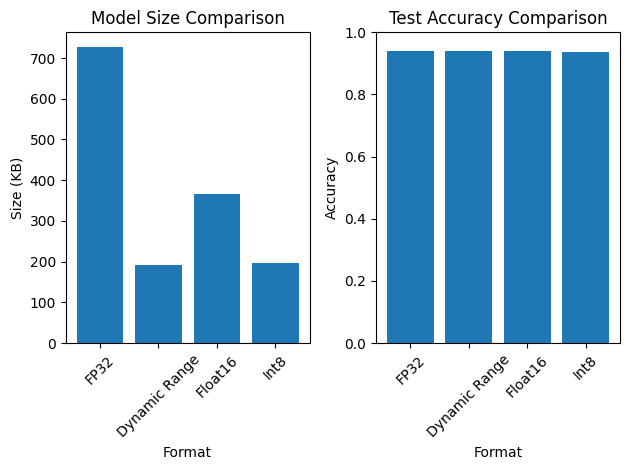

In [ ]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

# <-- Enter your code here <--#
# Model names for the x-axis
models = comparison_df["Format"]

# Bar plot for model size
plt.subplot(1,2,1)
plt.bar(models, comparison_df["Model Size (KB)"])
plt.title("Model Size Comparison")
plt.xlabel("Format")
plt.ylabel("Size (KB)")
plt.xticks(rotation=45)
plt.tight_layout()

# Bar plot for test accuracy
plt.subplot(1, 2, 2)
plt.bar(models, comparison_df["Test Accuracy"])
plt.title("Test Accuracy Comparison")
plt.xlabel("Format")
plt.ylabel("Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

### Confusion Matrix for the PTQ Int8 Model


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Classification Report for PTQ int8 Model:
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       496
           1       0.95      0.92      0.93       471
           2       0.95      0.94      0.94       420
           3       0.96      0.87      0.91       491
           4       0.86      0.96      0.91       532
           5       1.00      0.96      0.98       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



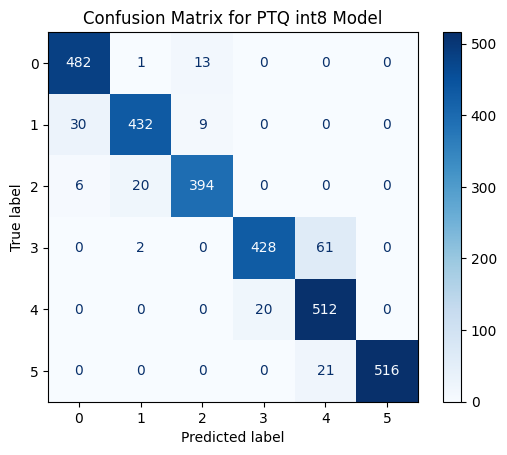

In [ ]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.

# <-- Enter your code here <--#

int8_acc, int8_pred = evaluate_tflite_model(tflite_int8, X_test, y_test)

y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

# Print classification report
print("Classification Report for PTQ int8 Model:")
print(classification_report(y_true, int8_pred))

# Plot confusion matrix
cm = confusion_matrix(y_true, int8_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap = "Blues", values_format="d")
plt.title("Confusion Matrix for PTQ int8 Model")
plt.show()

## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [ ]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

# <-- Enter your code here <--#
qat_model = tfmot.quantization.keras.quantize_model(baseline_model)
qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Fine-Tune the QAT Model


In [ ]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

# <-- Enter your code here <--#
history = qat_model.fit(
    X_train, y_train,  # Replace with your actual train data
    epochs=8,
    validation_split=0.2,
    batch_size=64,
    verbose=1
)

Epoch 1/8
92/92 [==============================] - 7s 36ms/step - loss: 0.0335 - accuracy: 0.9896 - val_loss: 0.1262 - val_accuracy: 0.9545
Epoch 2/8
92/92 [==============================] - 3s 29ms/step - loss: 0.0299 - accuracy: 0.9895 - val_loss: 0.1322 - val_accuracy: 0.9504
Epoch 3/8
92/92 [==============================] - 3s 28ms/step - loss: 0.0289 - accuracy: 0.9903 - val_loss: 0.1293 - val_accuracy: 0.9558
Epoch 4/8
92/92 [==============================] - 3s 34ms/step - loss: 0.0263 - accuracy: 0.9901 - val_loss: 0.1269 - val_accuracy: 0.9538
Epoch 5/8
92/92 [==============================] - 3s 29ms/step - loss: 0.0253 - accuracy: 0.9908 - val_loss: 0.1601 - val_accuracy: 0.9483
Epoch 6/8
92/92 [==============================] - 2s 23ms/step - loss: 0.0271 - accuracy: 0.9889 - val_loss: 0.1452 - val_accuracy: 0.9545
Epoch 7/8
92/92 [==============================] - 2s 25ms/step - loss: 0.0245 - accuracy: 0.9918 - val_loss: 0.1345 - val_accuracy: 0.9551
Epoch 8/8
92/92 [===

### Evaluate the QAT Keras Model


In [ ]:
# TODO:
# Evaluate the QAT Keras model on X_test.
# Print the test accuracy and classification report.

# <-- Enter your code here <--#
qat_loss, qat_acc = qat_model.evaluate(X_test, y_test, verbose=0)
print("QAT test accuracy:", qat_acc)

y_prob_qat = qat_model.predict(X_test, verbose=0)
y_pred_qat = np.argmax(y_prob_qat, axis=1)
print("Classification Report:")
print(classification_report(y_test, y_pred_qat, target_names=class_names))

QAT test accuracy: 0.9348490238189697
Classification Report:
                    precision    recall  f1-score   support

           WALKING       0.92      0.98      0.95       496
  WALKING_UPSTAIRS       0.94      0.90      0.92       471
WALKING_DOWNSTAIRS       0.96      0.94      0.95       420
           SITTING       0.96      0.87      0.91       491
          STANDING       0.85      0.96      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.94      2947
      weighted avg       0.94      0.93      0.94      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [ ]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

# <-- Enter your code here <--#
converter = tf.lite.TFLiteConverter.from_keras_model(qat_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8
qat_tflite_int8 = converter.convert()

# Save model and get size
qat_int8_size_kb = save_binary_model(qat_tflite_int8, 'qat_int8.tflite')

# Evaluate on test set
qat_int8_acc, qat_int8_pred = evaluate_tflite_model(qat_tflite_int8, X_test, y_test)
print("QAT int8 TFLite size (KB):", qat_int8_size_kb)
print("QAT int8 TFLite test accuracy:", qat_int8_acc)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:854: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


QAT int8 TFLite size (KB): 185.703125
QAT int8 TFLite test accuracy: 0.9348489989820156


## 12. PTQ Int8 vs QAT Int8


In [ ]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

# <-- Enter your code here <--#
comparison_df = pd.DataFrame({
    'Model': ['PTQ int8', 'QAT int8'],
    'Test Accuracy': [int8_acc, qat_int8_acc],
    'Model Size (KB)': [int8_size_kb, qat_int8_size_kb]
})
print(comparison_df)



      Model  Test Accuracy  Model Size (KB)
0  PTQ int8       0.937903       195.851562
1  QAT int8       0.934849       185.703125


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


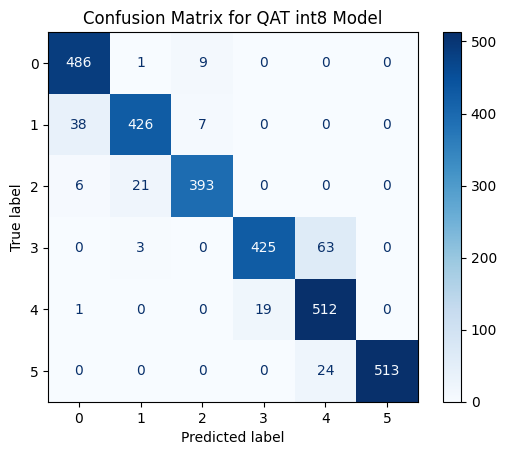

In [ ]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

# <-- Enter your code here <--#
qatint8_acc, qatint8_pred = evaluate_tflite_model(qat_tflite_int8, X_test, y_test)

y_true = np.argmax(y_test, axis=1) if len(y_test.shape) > 1 else y_test

cm = confusion_matrix(y_true, qatint8_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix for QAT int8 Model')
plt.show()

## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size?
  Dynamic Range quantization gave the smallest model size (~191 KB).

2. Which quantization method gave the best accuracy among the TensorFlow Lite models?
Dynamic Range quantization gave the best accuracy among TFLite models (0.9389).

3. Did QAT improve the final int8 model compared with PTQ int8?
No, QAT int8 (~0.938) was slightly worse than PTQ int8 (0.9379).

4. Why is this dataset a good fit for a DNN-based TinyML workflow?
Time-series sensor data with 561 extracted features is good for DNNs because it has fixed input size, high-dimensional features, and 6-class human activities map cleanly to softmax output.

5. If you were deploying this model on a resource-constrained device, which version would you choose and why?
Dynamic Range quantization - best accuracy (0.9389) with ~75% size reduction vs FP32, perfect balance for most resource-constrained devices.

## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.


In [ ]:
import zipfile
with zipfile.ZipFile('tflite_models.zip', 'w') as zf:
    for f in tflite_files:
        zf.write(f)
print("Created tflite_models.zip - download this!")

Created tflite_models.zip - download this!
